In [1]:
import torch, torchaudio
import numpy as np
from pathlib import Path
from omegaconf import OmegaConf
from hydra.utils import instantiate
import datetime
import matplotlib.pyplot as plt
from copy import deepcopy


In [2]:
def get_datapipe(config_data, batch_size, alter_seed_by=None):
    data_config = deepcopy(config_data)
    data_config.batch_size = batch_size

    # we may change the seed for different stages
    if alter_seed_by is not None:
        if "seed" in data_config:
            if data_config.seed is None:
                data_config.seed = alter_seed_by
            else:
                data_config.seed = config_data.seed + alter_seed_by
    return instantiate(data_config)

def get_loss_functions(config):
    if not "losses" in config: # backward compatibility
        loss_function = torch.nn.functional.mse_loss
        return {k: {"function": loss_function, "weight": config.losses_weights.get(k, 1.0)} for k in ["clean", "noised", "response"]}
    loss_functions = {}
    for loss_name, loss_info in config.losses.items():
        if loss_info.function == "mse":
            loss_function = torch.nn.functional.mse_loss
        elif loss_info.function == "mae":
            loss_function = torch.nn.functional.l1_loss
        else:
            raise ValueError(f"Unsupported loss function: {loss_info.function}")
        loss_functions[loss_name] = {
            "function": loss_function,
            "weight": loss_info.weight
        }
    return loss_functions



In [10]:
run_dir = Path("/home/mbuk/scratch/mbuk/nmr/projects/01_shimator/shimnet/runs/model_experiments/03_MAE_newmodel_smoothstretchedSCRF")
config = OmegaConf.load(run_dir / "config.yaml")
config.data.response_generator.response_function_library.response_files = ["../" + f for f in config.data.response_generator.response_function_library.response_files]
config.data.clean_spectra_generator.peaks_parameter_generator.atom_groups_data_file = "../" + config.data.clean_spectra_generator.peaks_parameter_generator.atom_groups_data_file
device = "cpu"
model = instantiate(config.model).to(device)
model_weights_file = run_dir / f'model.pt'
model.load_state_dict(torch.load(model_weights_file, map_location=device))
data_pipe = get_datapipe(config.data, batch_size=64)
loss_calculation = get_loss_functions(config)


/tmp/ipykernel_2079456/2456473389.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_weights_file, map_location=device))


In [25]:
batch = next(iter(data_pipe))

In [26]:
out = model(batch['noised_spectrum'].to(device))


In [27]:
# calculate losses
loss_response = loss_calculation["response"]["function"](out['response'], batch['response_function'].squeeze(dim=(1,2)).to(device))
loss_clean = loss_calculation["clean"]["function"](out['denoised'], batch['theoretical_spectrum'].to(device))
noised_est = torchaudio.functional.convolve(out['denoised'], out['response'].flip(dims=(-1,)).unsqueeze(1), mode="same")
loss_noised = loss_calculation["noised"]["function"](noised_est, batch['noised_spectrum'].to(device))
loss = loss_calculation["response"]["weight"]*loss_response + loss_calculation["clean"]["weight"]*loss_clean + loss_calculation["noised"]["weight"]*loss_noised
#
print(f"Total loss: {loss.item():.6f} (response: {loss_response.item():.6f}, clean: {loss_clean.item():.6f}, noised: {loss_noised.item():.6f})")

Total loss: 0.014195 (response: 0.002684, clean: 0.004173, noised: 0.007338)


In [28]:
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)


tensor(0.1832)

In [29]:
model

ShimnetModular(
  (encoder): ConvEncoder(
    (net): Sequential(
      (0): Conv1d(1, 64, kernel_size=(7,), stride=(1,))
      (1): GELU(approximate='none')
      (2): Dropout(p=0, inplace=False)
      (3): Conv1d(64, 64, kernel_size=(7,), stride=(1,))
      (4): GELU(approximate='none')
      (5): Dropout(p=0, inplace=False)
      (6): Conv1d(64, 64, kernel_size=(7,), stride=(1,))
      (7): GELU(approximate='none')
      (8): Dropout(p=0, inplace=False)
      (9): Conv1d(64, 128, kernel_size=(7,), stride=(1,))
      (10): GELU(approximate='none')
      (11): Dropout(p=0, inplace=False)
    )
  )
  (attention_module): KVAttention(
    (k_processor): ConvMLP(
      (mlp): Sequential(
        (0): Conv1d(128, 512, kernel_size=(1,), stride=(1,))
        (1): GELU(approximate='none')
        (2): Conv1d(512, 256, kernel_size=(1,), stride=(1,))
        (3): GELU(approximate='none')
        (4): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
      )
    )
    (v_processor): MLP(
      (mlp

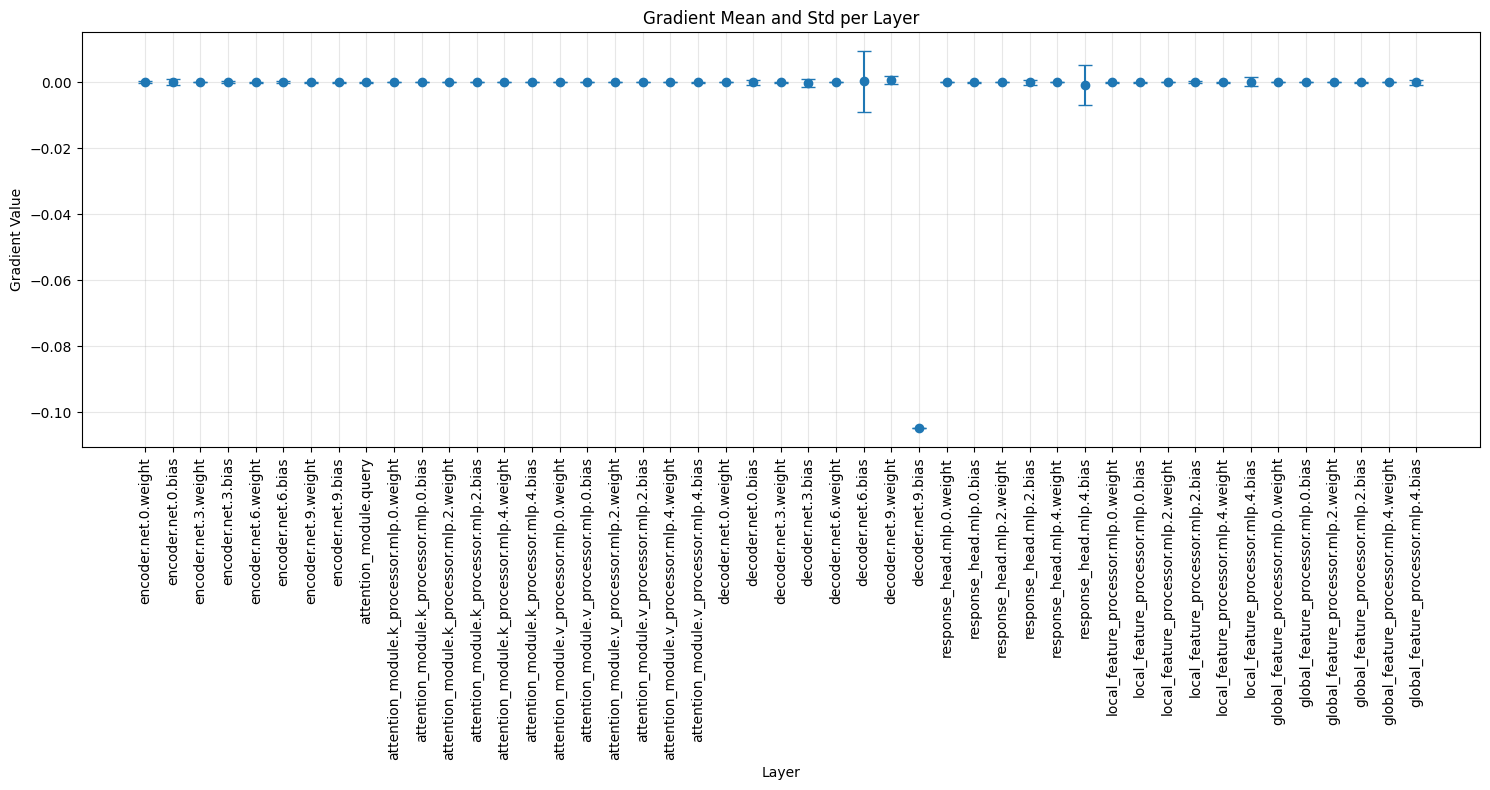

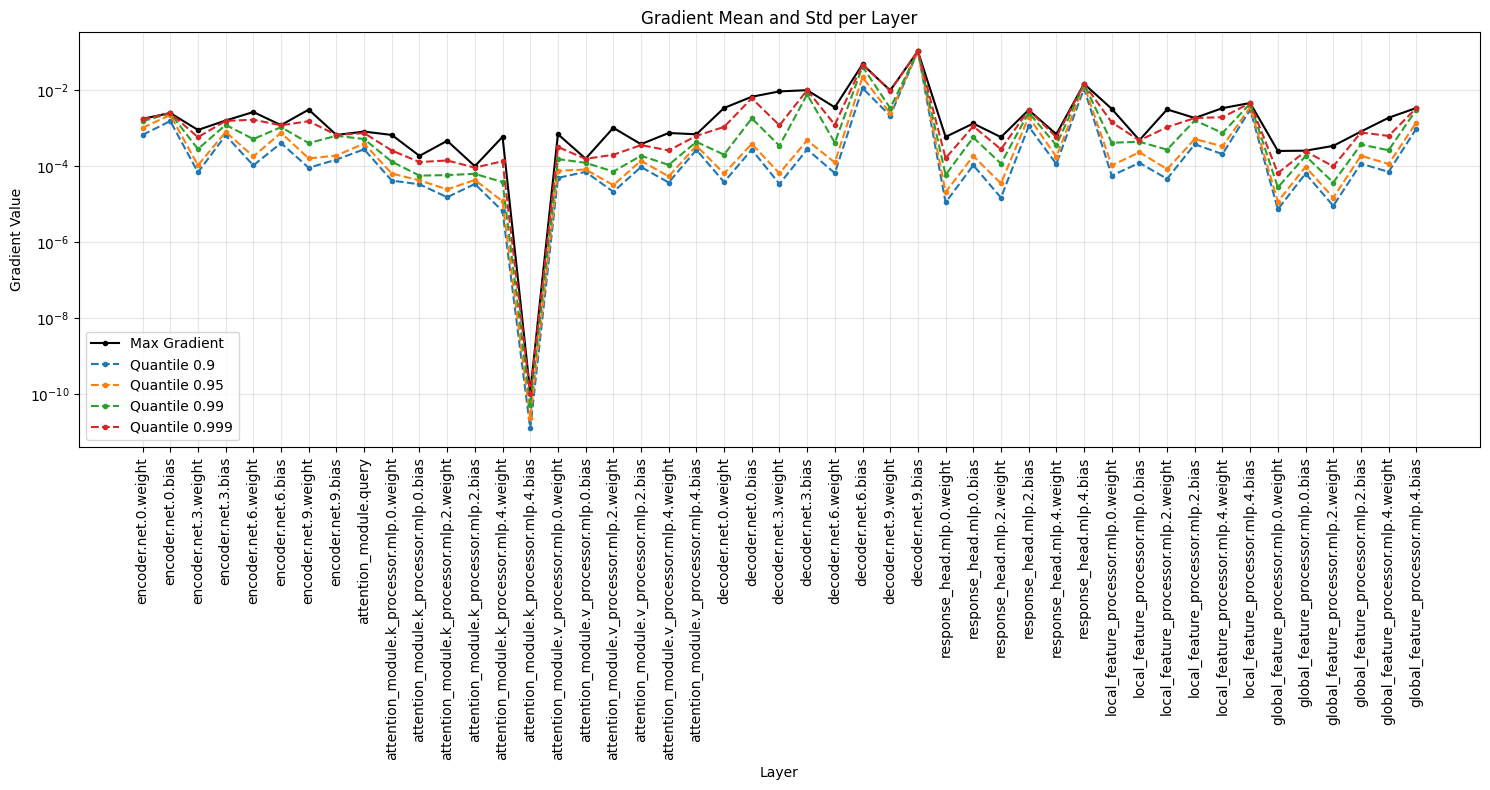

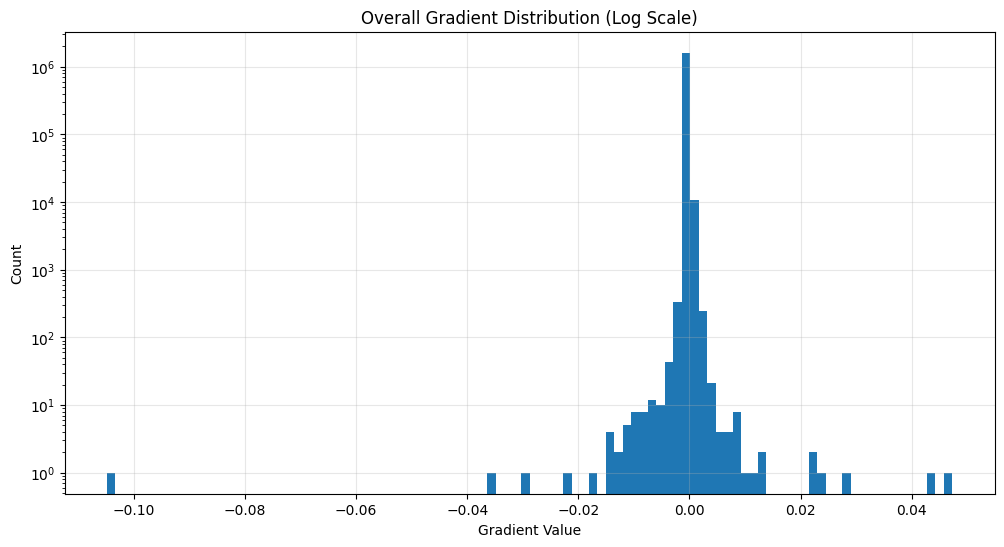

In [30]:
# Collect gradients
grad_means = []
grad_stds = []
layer_names = []
all_grads = []

for name, param in model.named_parameters():
    if param.grad is not None:
        grad = param.grad.detach().cpu().numpy()
        grad_means.append(np.mean(grad))
        grad_stds.append(np.std(grad))
        layer_names.append(name)
        all_grads.append(grad.flatten())

# Plot Mean and Std of gradients per layer
plt.figure(figsize=(15, 8))
plt.errorbar(range(len(layer_names)), grad_means, yerr=grad_stds, fmt='o', capsize=5)
plt.xticks(range(len(layer_names)), layer_names, rotation=90)
plt.title("Gradient Mean and Std per Layer")
plt.xlabel("Layer")
plt.ylabel("Gradient Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Max and Quantiles of gradients per layer
grad_maxes = []
quantiles = [0.9, 0.95, 0.99, 0.999]
grad_quantiles = {q: [] for q in quantiles}
np.quantile(all_grads[0], quantiles)
for grad in all_grads:
    abs_grad = np.abs(grad)
    grad_maxes.append(np.max(abs_grad))
    qs = np.quantile(abs_grad, quantiles)
    for q_val, q in zip(qs, quantiles):
        grad_quantiles[q].append(q_val)


plt.figure(figsize=(15, 8))
plt.semilogy(range(len(layer_names)), grad_maxes, marker='.', label='Max Gradient', color='black')
for q in quantiles:
    plt.semilogy(range(len(layer_names)), grad_quantiles[q], marker='.', linestyle='--', label=f'Quantile {q}')
plt.legend()
plt.xticks(range(len(layer_names)), layer_names, rotation=90)
plt.title("Gradient Mean and Std per Layer")
plt.xlabel("Layer")
plt.ylabel("Gradient Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Histogram of all gradients
if all_grads:
    all_grads_concat = np.concatenate(all_grads)
    plt.figure(figsize=(12, 6))
    plt.hist(all_grads_concat, bins=100, log=True)
    plt.title("Overall Gradient Distribution (Log Scale)")
    plt.xlabel("Gradient Value")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.show()


In [31]:
def analyze_batch(batch, clip_grad=True):
    for p in model.parameters():
        p.grad = None

    out = model(batch['noised_spectrum'].to(device))

    # calculate losses
    loss_response = loss_calculation["response"]["function"](out['response'], batch['response_function'].squeeze(dim=(1,2)).to(device))
    loss_clean = loss_calculation["clean"]["function"](out['denoised'], batch['theoretical_spectrum'].to(device))
    noised_est = torchaudio.functional.convolve(out['denoised'], out['response'].flip(dims=(-1,)).unsqueeze(1), mode="same")
    loss_noised = loss_calculation["noised"]["function"](noised_est, batch['noised_spectrum'].to(device))
    loss = loss_calculation["response"]["weight"]*loss_response + loss_calculation["clean"]["weight"]*loss_clean + loss_calculation["noised"]["weight"]*loss_noised
    #
    print(f"Total loss: {loss.item():.6f} (response: {loss_response.item():.6f}, clean: {loss_clean.item():.6f}, noised: {loss_noised.item():.6f})")

    loss.backward()
    if clip_grad:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)

    # Collect gradients
    grad_means = []
    grad_stds = []
    layer_names = []
    all_grads = []

    for name, param in model.named_parameters():
        if param.grad is not None:
            grad = param.grad.detach().cpu().numpy()
            grad_means.append(np.mean(grad))
            grad_stds.append(np.std(grad))
            layer_names.append(name)
            all_grads.append(grad.flatten())

    # Plot Mean and Std of gradients per layer
    plt.figure(figsize=(15, 8))
    plt.errorbar(range(len(layer_names)), grad_means, yerr=grad_stds, fmt='o', capsize=5)
    plt.xticks(range(len(layer_names)), layer_names, rotation=90)
    plt.title("Gradient Mean and Std per Layer")
    plt.xlabel("Layer")
    plt.ylabel("Gradient Value")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot Max and Quantiles of gradients per layer
    grad_maxes = []
    quantiles = [0.9, 0.95, 0.99, 0.999]
    grad_quantiles = {q: [] for q in quantiles}
    np.quantile(all_grads[0], quantiles)
    for grad in all_grads:
        abs_grad = np.abs(grad)
        grad_maxes.append(np.max(abs_grad))
        qs = np.quantile(abs_grad, quantiles)
        for q_val, q in zip(qs, quantiles):
            grad_quantiles[q].append(q_val)


    plt.figure(figsize=(15, 8))
    plt.semilogy(range(len(layer_names)), grad_maxes, marker='.', label='Max Gradient', color='black')
    for q in quantiles:
        plt.semilogy(range(len(layer_names)), grad_quantiles[q], marker='.', linestyle='--', label=f'Quantile {q}')
    plt.legend()
    plt.xticks(range(len(layer_names)), layer_names, rotation=90)
    plt.title("Gradient Mean and Std per Layer")
    plt.xlabel("Layer")
    plt.ylabel("Gradient Value")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot Histogram of all gradients
    if all_grads:
        all_grads_concat = np.concatenate(all_grads)
        plt.figure(figsize=(12, 6))
        plt.hist(all_grads_concat, bins=100, log=True)
        plt.title("Overall Gradient Distribution (Log Scale)")
        plt.xlabel("Gradient Value")
        plt.ylabel("Count")
        plt.grid(True, alpha=0.3)
        plt.show()




In [38]:
model.decoder.net[9].bias.grad

tensor([-0.0906])

In [32]:
from itertools import islice

data_pipe = get_datapipe(config.data, batch_size=1)
batches = [batch for batch in islice(data_pipe, 3)]

Total loss: 0.014312 (response: 0.002197, clean: 0.006757, noised: 0.005358)


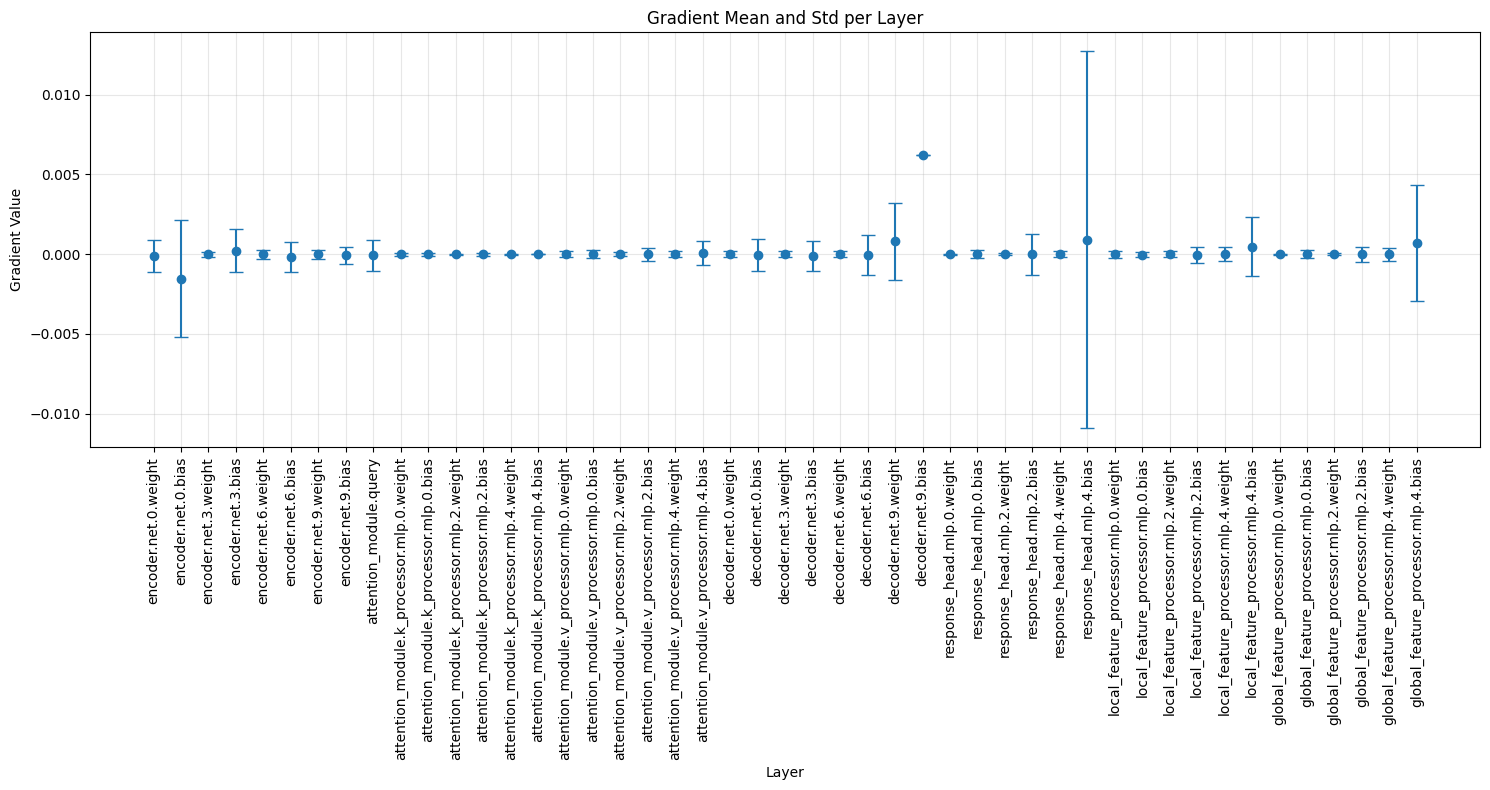

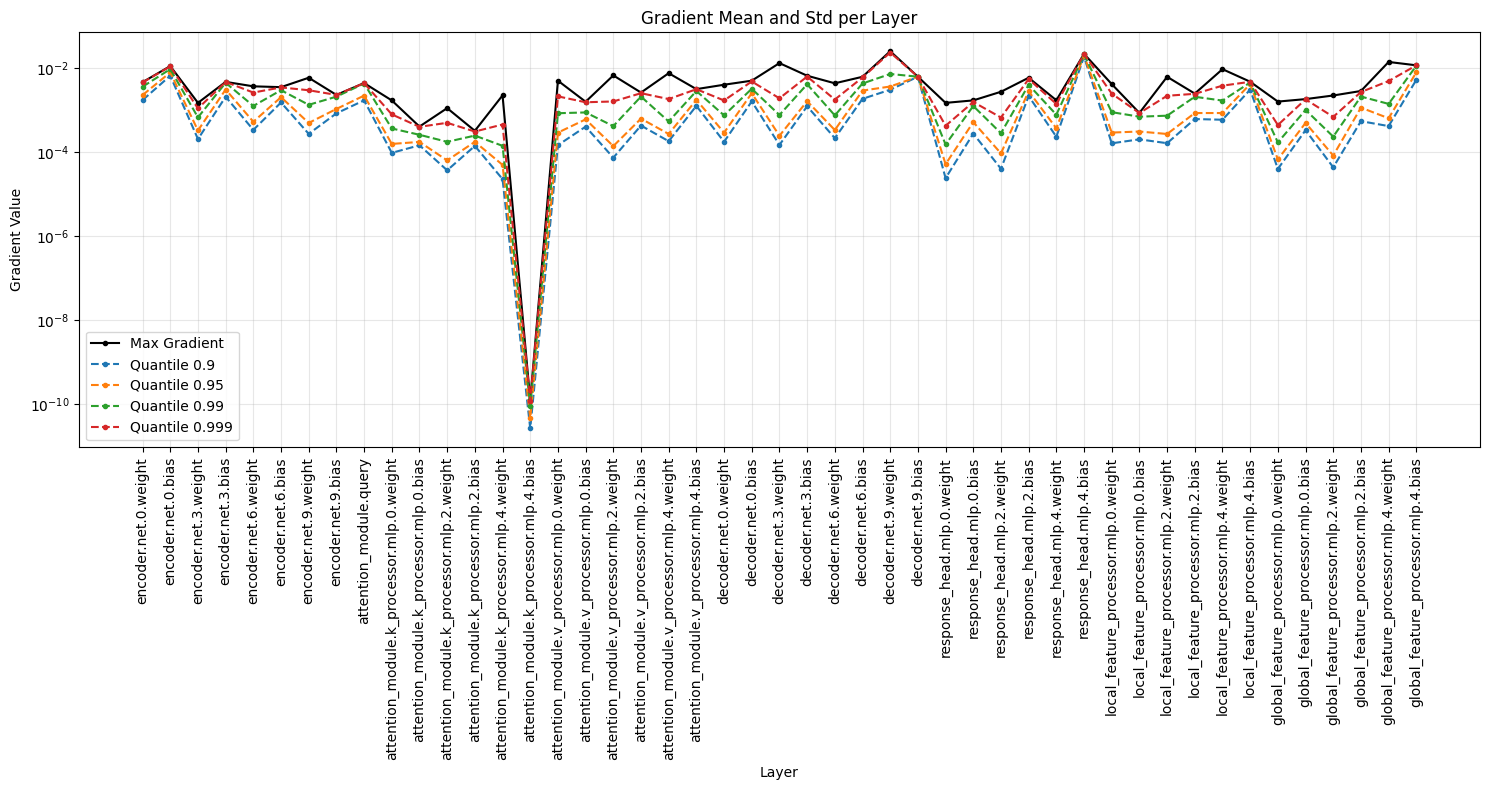

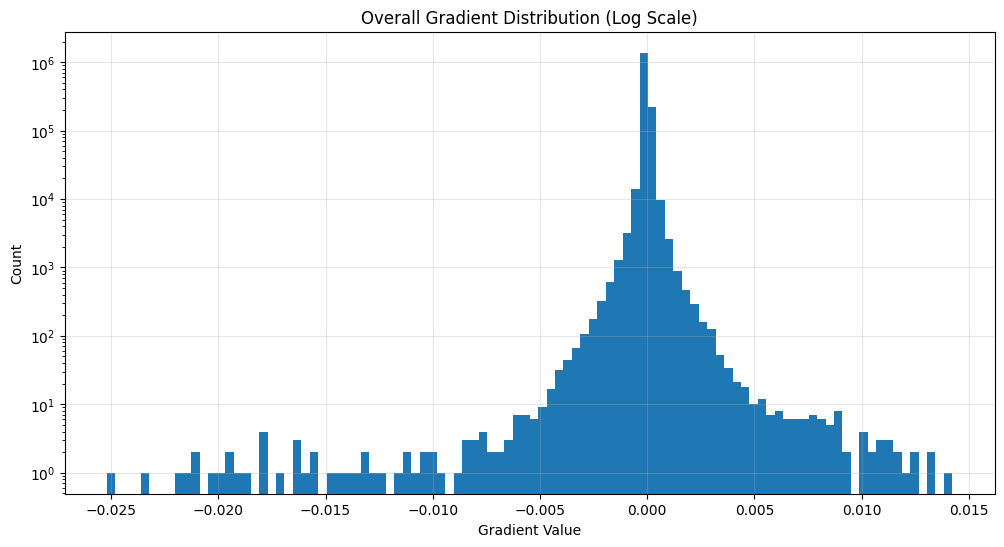

In [39]:
analyze_batch(batches[2])